
# Control por realimentación de estado
---

In [2]:
# Instalar paquetes necesarios (solo la primera vez)
using Pkg
Pkg.add(["ControlSystems", "ControlSystemsBase", "Plots", "LinearAlgebra", "LaTeXStrings"])

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using ControlSystems
using ControlSystemsBase
using LinearAlgebra
using Plots
using LaTeXStrings

# Configurar backend de gráficas
gr()

Plots.GRBackend()

---
## 2. Control de sistema de Tanques

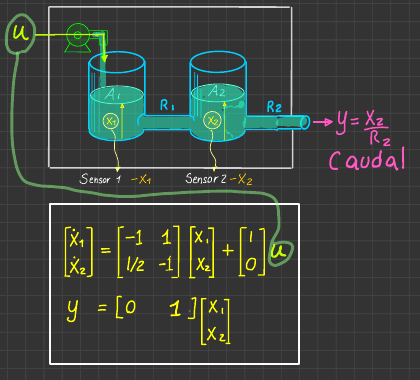


Sistema de dos tanques en cascada con dinámica:

$$\dot{x} = \begin{bmatrix} -1 & 1 \\ 1/2 & -1 \end{bmatrix} x + \begin{bmatrix} 1 \\ 0 \end{bmatrix} u, \quad y = \begin{bmatrix} 0 & 1 \end{bmatrix} x$$

**Especificaciones de diseño:**
- $SP \leq 1\%$
- $t_{ee} \leq 60\,s$
- $t_r \leq 10\,s$

In [3]:
# Modelo del sistema de tanques en lazo abierto
A = [-1.0  1.0 1.0;
        0.5 -1.0 0.0;
        0.0 7.0 -1.0]
B = [1.0; 0.0; 0.0]


C = [0.0  1.0 0.0]
D = 0.0

tanque_la = ss(A, B, C, D)
K=place(A, B, [-2.0, -3.0, -4.0])  # Ganancias del controlador por asignación de polos
println("Sistema de tanques en lazo abierto:\n")
print(tanque_la)

println("\nValores propios del sistema de tanques:")
print((eigvals(A)))

Sistema de tanques en lazo abierto:

StateSpace{Continuous, Float64}
A = 
 -1.0   1.0   1.0
  0.5  -1.0   0.0
  0.0   7.0  -1.0
B = 
 1.0
 0.0
 0.0
C = 
 0.0  1.0  0.0
D = 
 0.0

Continuous-time state-space model
Valores propios del sistema de tanques:
ComplexF64[-1.8139446252134448 - 1.2196382901260372im, -1.8139446252134448 + 1.2196382901260372im, 0.6278892504268887 + 0.0im]

### Selección de polos
Usando las especificaciones, seleccione los polos apropiados, los que están solo son un ejemplo

In [ ]:
# Asignación de polos para el sistema de tanques
polos_lc =  [-1, -1]

K = place(A, B, polos_lc)
println("Ganancia K para tanques:")
print(K)

# Verificar
println("\nValores propios en lazo cerrado:")
print(eigvals(A - B * K))

# Ganancia de prealimentación
ref = 0.5
kr = 1/(-C * inv(A - B*K) * B)[1]
println("\nGanancia de prealimentación kr = ", round(kr, digits=4))

Ganancia K para tanques:
[0.0 1.0]
Valores propios en lazo cerrado:
[-1.0, -1.0]
Ganancia de prealimentación kr = 2.0


## Respuesta en lazo cerrado

In [1]:
# Sistema de tanques en lazo cerrado
tanques_lc = ss(A - B *K, B * kr, C, D)

# Respuesta al escalón de amplitud r
t = 0:0.1:30.0
Y, t, X = step(tanques_lc*ref , t)


plot(t, Y',
     xlabel="Tiempo [s]", ylabel="Nivel y₂",
     title="Respuesta al escalón — Sistema de Tanques en Lazo Cerrado",
     label="Salida y", lw=2, color=:blue)
hline!([ref], label="Referencia r=$(ref)", lw=1, ls=:dash, color=:green)

LoadError: UndefVarError: `ss` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Señal de control $u = k_r r - Kx$

In [1]:
# Señal de control: u = kr*r - K*x

u_control = kr * ref .- (K * X)   # (1 × nt)

u_max = maximum(abs.(u_control))
println("Máximo valor absoluto de la señal de control: ", round(u_max, digits=4))

p1 = plot(t, Y',
          xlabel="Tiempo [s]", ylabel="Nivel y₂",
          title="Salida del sistema",
          label="y", lw=2, color=:blue)
hline!(p1, [ref], label="Referencia", lw=1, ls=:dash, color=:gray)

p2 = plot(t, u_control',
          xlabel="Tiempo [s]", ylabel="u",
          title="Señal de control u = kr*r - K*x",
          label="u(t)", lw=2, color=:red)

plot(p1, p2, layout=(2,1), size=(700, 500))

LoadError: UndefVarError: `kr` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

---
## 3. Control de un robot de dos ruedas tipo pendulo inverso.

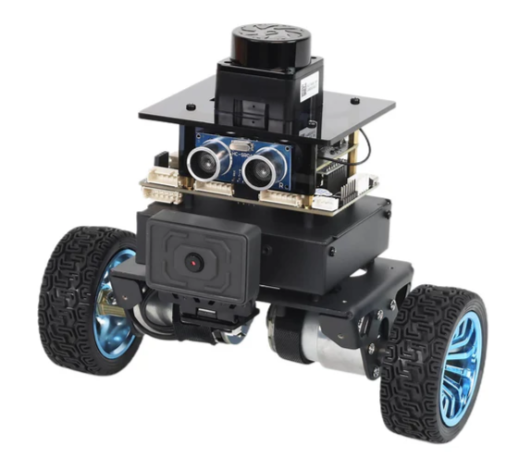

El modelo matemático de un robot de 2 ruedas (tipo péndulo inverso) linealizado en el equilibrio $x = 0$ está dado por:
$$
\begin{bmatrix}
\dot{x}_1 \\ 
\dot{x}_2 \\ 
\dot{x}_3 \\ 
\dot{x}_4
\end{bmatrix} 
= 
\begin{bmatrix}
0 & 1 & 0 & 0 \\ 
0 & -(I+ml^2)b/p & m^2gl^2/p & 0 \\ 
0 & 0 & 0 & 1 \\ 
0 & -mlb/p & mgl(M+m)/p & 0
\end{bmatrix} 
\begin{bmatrix}
x_1 \\ 
x_2 \\ 
x_3 \\ 
x_4
\end{bmatrix} 
+ 
\begin{bmatrix}
0 \\ 
(I+ml^2)/p \\ 
0 \\ 
ml/p
\end{bmatrix} 
u
$$

**Variables de estado:**
- $x_1$: Posición lineal del robot
- $x_2$: Velocidad lineal del robot
- $x_3$: Ángulo de inclinación del robot
- $x_4$: Velocidad angular en la inclinación del robot
- $u$: Torque aplicado por los motores

In [16]:
# Parámetros del robot de 2 ruedas
M_r = 1.0       # masa del chasis [kg]
m_r = 0.2       # masa de las ruedas y eje [kg]
b_r = 0.1       # coeficiente de fricción viscosa [N·m·s]
I_r = 0.0005    # momento de inercia del péndulo [kg·m²]
l_r = 0.3       # longitud del péndulo [m]
g_r = 9.8       # aceleración gravitacional [m/s²]

p_r = (M_r + m_r)*(I_r + m_r*l_r^2) - (m_r*l_r)^2


A_r = [0    1                         0                  0;
       0  -(I_r+m_r*l_r^2)*b_r/p_r  (m_r^2*g_r*l_r^2)/p_r  0;
       0    0                         0                  1;
       0  -(m_r*l_r*b_r)/p_r       m_r*g_r*l_r*(M_r+m_r)/p_r  0]

B_r = [0;
       (I_r + m_r*l_r^2)/p_r;
       0;
       m_r*l_r/p_r]

C_r = Matrix{Float64}(I, 4, 4)
D_r = zeros(4, 1)

robot_segway = ss(A_r, B_r, C_r, D_r)

println("\nA del robot:")
display(A_r)
println("\nValores propios del robot (lazo abierto):")
display(eigvals(A_r))


A del robot:


4×4 Matrix{Float64}:
 0.0   1.0         0.0      0.0
 0.0  -0.0994624   1.89677  0.0
 0.0   0.0         0.0      1.0
 0.0  -0.322581   37.9355   0.0


Valores propios del robot (lazo abierto):


4-element Vector{Float64}:
 -6.167359232527252
 -0.0833303804321428
  0.0
  6.151227247367996

---
## Actividad 1: Controlador por realimentación de estado para el robot segway

**Sugerencia:** Use un par de polos de segundo orden con valores apropiados para un tiempo de establecimiento razonable $-\sigma \pm j\omega_d$, y otro par de polos lejanos con $\omega$ al menos 2-3 veces mayor.

In [17]:
# ========================
# ACTIVIDAD 1: Complete aquí el diseño del controlador
# ========================



polos_robot = [-1, -2, -3, -4]
println("Polos deseados: ", polos_robot)

# Calcular ganancia por asignación de polos
K = place(A_r, B_r, polos_robot)
println("\nGanancia K:")
print(K)

println("\nVerificación — Polos en lazo cerrado:")
print(eigvals(A_r - B_r * K))


Polos deseados: [-1, -2, -3, -4]

Ganancia K:
[-0.7591836734693875 -1.681632653061224 22.844081632653065 3.5876700680272102]
Verificación — Polos en lazo cerrado:
[-3.999999999999986, -3.0000000000000537, -1.9999999999999558, -1.0000000000000087]

kr robot = -0.7592


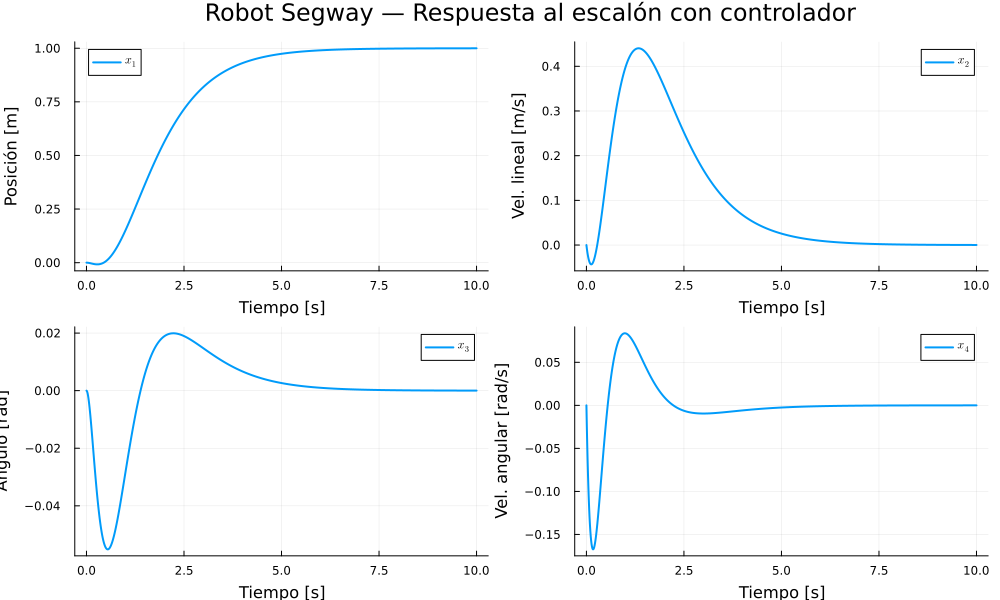

In [19]:
# Controlador con seguimiento de posición x1

C1_r = [1.0 0.0 0.0 0.0]   # salida: posición x1
kr = -1/(C_r * inv(A_r - B_r*K) * B_r)[1]
println("kr robot = ", round(kr, digits=4))

robot_lc = ss(A_r - B_r*K, B_r*kr, C_r, D_r)

# Respuesta al escalón (posición)
t_r = 0:0.01:10
ref_r = ones(1, length(t_r))
Y_r, t_r_out, X_r = lsim(robot_lc, ref_r, t_r)

labels_r = [L"x_1" L"x_2" L"x_3" L"x_4"]
ylabels_r = ["Posición [m]" "Vel. lineal [m/s]" "Ángulo [rad]" "Vel. angular [rad/s]"]

p_rob = plot(layout=(2,2), size=(1000,600),
             suptitle="Robot Segway — Respuesta al escalón con controlador")
for i in 1:4
    plot!(p_rob[i], t_r_out, Y_r[i,:],
          label=labels_r[i], xlabel="Tiempo [s]", ylabel=ylabels_r[i], lw=2)
end
display(p_rob)

## Señal de control en el robot

Máxima señal de control |u|_max = 0.8074 [N·m]


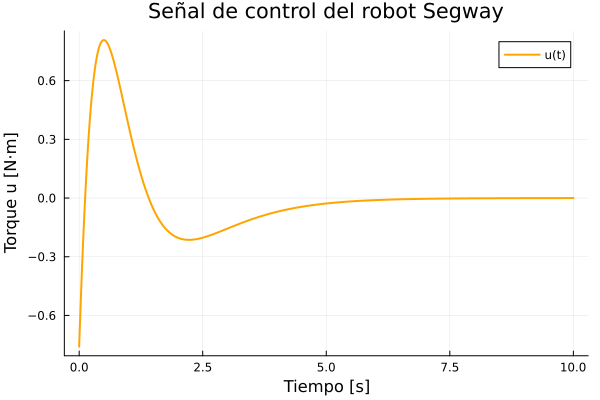

In [23]:
# Señal de control del robot
r_val = 1.0
u_robot = kr * r_val .- (K * X_r)

println("Máxima señal de control |u|_max = ", round(maximum(abs.(u_robot)), digits=4), " [N·m]")

plot(t_r_out, u_robot[1,:],
     xlabel="Tiempo [s]", ylabel="Torque u [N·m]",
     title="Señal de control del robot Segway",
     label="u(t)", lw=2, color=:orange)